# Homework set 4

Please **submit this Jupyter notebook through Canvas** no later than **Monday December 9, 9:00**. **Submit the notebook file with your answers (as .ipynb file) and a pdf printout. The pdf version can be used by the teachers to provide feedback. On canvas there are hints about creating a nice pdf version.**

Before you hand in, please make sure the notebook runs, by running "Restart kernel and run all cells..." from the Kernel menu.

Homework is in **groups of two**, and you are expected to hand in original work. Work that is copied from another group will not be accepted.

# Exercise 0
Write down the names + student ID of the people in your group.

Format: Name [ID]

1. Kushnava Singha [15663388] <br>
2. Shania Sinha [14379031]

Run the following cell to import NumPy, Matplotlib. If anything else is needed you can import this yourself.

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sympy import *
from tqdm import tqdm

# Exercise 1
N.B.1. you are to implement the methods yourself.

N.B.2. Tentative distribution of points is 2+1+2+2+2 points (plus 1 point makes 10).

Given a function $f$, let $T(f,a,b,m)$ denote the composite trapezoid rule with $m$ subintervals over the interval $[a,b]$. 

## (a)
Approximate the integral of $x^{-3}$ over $[a,b] = [ \frac{1}{10}, 100 ]$ by the composite trapezoid rule $T(f,a,b,m)$ for $m = 2^k$. Plot the absolute approximation error for different values of $k$. Find the smallest $k$ such that the exact error is less than $\epsilon = 10^{-3}$. Explain the slow convergence.

In [116]:
def composite_trapezoid(f, a, b, m):
    h = (b - a) / m              # Length of subintervals
    x = np.arange(a, b, h)       # Subinterval end points
    y = f(x)                     # Function values at end points
    
    return h * ((1/2) * y[0] + np.sum(y[1:-1]) + (1/2) * f(b))

In [79]:
# Parameters
a = 0.1
b = 100
k = np.linspace(0, 28, 1000)
m = 2**k
tol = 1e-3      # epsilon

In [80]:
x = symbols('x')
f = lambda x: x**-3
f_prime = diff(x**-3, x)                # First differential
f_double_prime = diff(x**-3, x, 2)      # Second differential

In [81]:
# Get absolute approximation errors for each estimate 
def error(f_double_prime, a, b, x, m):
    h = (b - a) / m
    return h**2 * integrate(f_double_prime, (x, a, b)) / 12

In [83]:
# Get composite_trapezoid estimated area
estimated_area = [composite_trapezoid(f, a, b, int(value)) for value in tqdm(m)]

100%|██████████| 1000/1000 [09:32<00:00,  1.75it/s] 


In [ ]:
# Get absolute approximation errors for each estimate
absolute_approximation_errors = [error(f_double_prime, a, b, x, value) for value in tqdm(m)]

100%|██████████| 1000/1000 [00:19<00:00, 51.14it/s]


In [107]:
# The smallest value of k such that the exact error is less than tol
exact_value = integrate(x**-3, (x, a, b))
exact_error = [np.abs(area - exact_value) for area in estimated_area]
min_good_k = k[np.where(np.array(exact_error) < tol)][0]
print(f"The smallest value of k such that the exact error is less than tol is: {min_good_k:.3f}")

The smallest value of k such that the exact error is less than tol is: 17.293


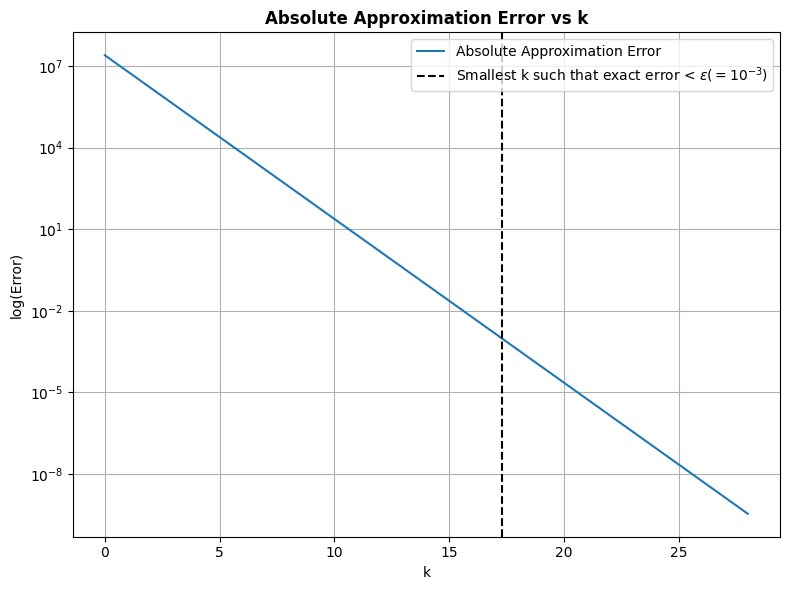

In [109]:
# Plot error vs k
plt.figure(figsize=(8, 6))
plt.plot(k, absolute_approximation_errors, label='Absolute Approximation Error')
plt.axvline(min_good_k, color='black', linestyle='--', label='Smallest k such that exact error < $\epsilon (=10^{-3})$')
# plt.axhline(tol, color='red', linestyle='--', label='Tolerance')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel('log(Error)')
plt.title('Absolute Approximation Error vs k', fontweight='bold')
plt.legend(loc='upper right')
plt.grid()
plt.tight_layout()
plt.show()

***Answer:***

add; explain slow convergence

## (b)

To improve the convergence rate of the above problem, we may use an adaptive strategy, as discussed in the book and the lecture. Consider the following formulas for approximate integration
$$I_1(f,a,b) = T(f,a,b,1)$$
$$I_2(f,a,b) = T(f,a,b,2).$$
Show, based on the precise error estimates for the trapezoid rule from the book/lecture that the error in $I_2$ can be estimated by a formula of the form 
$$E_2 = C (I_1 - I_2)$$
and determine the constant $C$ (if you can't find $C$, you may take $C = 0.5$).

## (c)
An adaptive strategy for computing the integral on an interval $[a,b]$ now is: Compute $I_2$ and $E_2$, and accept $I_2$ as an approximation when the estimated error $E_2$ is less or equal than a desired tolerance $\epsilon$.  Otherwise, apply the procedure to 
$\int_a^{\frac{b+a}{2}} f(x) \, dx$ and $\int_{\frac{b+a}{2}}^b f(x) \, dx$ with tolerances $\frac{\epsilon}{2}$.

Write a recursive python routine that implements the adaptive strategy.

Then apply this routine to the function $x^{-3}$ with $a, b, \epsilon$ as before. What is the exact error in the obtained approximation? 

In [ ]:
# def adaptquad(f, a, b, tol):
#     I_1 = composite_trapezoid(f, a, b, 1)   # I_1: Quadrature 1
#     I_2 = composite_trapezoid(f, a, b, 2)   # I_2: Quadrature 2
    
#     E_2 = np.abs(1/3 * (I_1 - I_2))         # Error 2 estimate
    
#     m = a + (b - a) / 2                           # Midpoint
    
#     if m <= a or m >= b:
#         # warnings.warn("Error: m is not within the interval")
#         return I_2
#     elif E_2 < tol:
#         return I_2
#     else:
#         new_tol = tol / 2
#         # print(f'new tol: {tol/2}')
#         return adaptquad(f, a, m, new_tol) + adaptquad(f, m, b, new_tol)

In [ ]:
# Adaptive approximation
adaptive_approximation = adaptquad(f, a, b, tol)
print(f'Adaptive Approximation: {adaptive_approximation}')

# Exact value
exact_value = integrate(x**-3, (x, a, b))
print(f'Exact Value: {exact_value}')

# Error
exact_error = abs(adaptive_approximation - exact_value)
print(f'Error: {exact_error}')

KeyboardInterrupt: 

## (d)

Modify the code of (c) so that the number of function evaluations is counted. Optimize your implementation such that no unnecessary function evaluations are performed.

Compare the number of function evaluations used in the adaptive strategy of (c) with the result of (a). 
(*Hint*: To count the number of function evaluations, you may use a global variable.)


In [119]:
# Initialize a global counter for function evaluations
function_evaluations = 0

# Updated composite trapezoid rule with function evaluation counting
def composite_trapezoid_count(f, a, b, m):
    global function_evaluations
    h = (b - a) / m               # Length of subintervals
    x = np.linspace(a, b, m+1)    # Subinterval end points
    y = f(x)                      # Function values at end points
    function_evaluations += len(x)  # Count function evaluations
    return h * ((1/2) * y[0] + np.sum(y[1:-1]) + (1/2) * y[-1])

# Adaptive integration with evaluation counting and caching
def adaptive_trapezoid_count(f, a, b, tol, fa=None, fb=None, fm=None, min_interval=1e-10):
    global function_evaluations
    
    # Check if the interval size is too small
    if abs(b - a) < min_interval:
        return 0

    # Use cached function values if provided, otherwise evaluate
    if fa is None:
        fa = f(a)
        function_evaluations += 1
    if fb is None:
        fb = f(b)
        function_evaluations += 1
    if fm is None:
        mid = (a + b) / 2
        fm = f(mid)
        function_evaluations += 1
    else:
        mid = (a + b) / 2

    # Compute trapezoid approximations using cached values
    I1 = (b - a) * (fa + fb) / 2
    I2 = (b - mid) * (fa + fm) / 2 + (mid - a) * (fm + fb) / 2

    # Estimate the error using the corrected constant C = -2/3
    E2 = 1/3 * (I1 - I2)

    # If the error is within tolerance, return the refined approximation
    if abs(E2) <= tol:
        return I2
    else:
        # Apply recursion with caching
        left_result = adaptive_trapezoid_count(f, a, mid, tol / 2, fa, fm, None, min_interval)
        right_result = adaptive_trapezoid_count(f, mid, b, tol / 2, fm, fb, None, min_interval)
        return left_result + right_result

# Reset evaluation counter
function_evaluations = 0

# Compute the adaptive approximation with evaluation counting
adaptive_approximation = adaptive_trapezoid_count(f, a, b, tol)

# # Calculate the exact error
# adaptive_exact_error = abs(exact_value - adaptive_approximation)

adaptive_approximation, exact_value, function_evaluations


(50.00014849011892, 49.9999500000000, 9671)

## (e)
In the course of executing the recursive procedure, some subintervals are refined (split into two subintervals) while others aren't as a result of the choices made by the algorithm. It turns out that the choices made by this algorithm are not always optimal. Other algorithms, that decide in a different way which subinterval needs to be refined, may be more efficient in the sense that they require less function evaluations (while using the same formulas for the approximate integral and the approximate error associated with a subinterval).

Can you explain why this is the case? Devise an alternative, non-recursive algorithm that addresses this issue and should to lead a more efficient integral computation. Describe your approach and algorithm in about 5 to 10 sentences (bullet points).
